# Notebook 19: Variational Autoencoders with Keras and MNIST

## Learning Goals
The goals of this notebook is to learn how to code a variational autoencoder in Keras. We will discuss hyperparameters, training, and loss-functions. In addition, we will familiarize ourselves with the Keras sequential GUI as well as how to visualize results and make predictions using a VAE with a small number of latent dimensions.

## Overview

This notebook teaches the reader how to build a Variational Autoencoder (VAE) with Keras. The code is a minimally modified, stripped-down version of the code from Lous Tiao in his wonderful [blog post](http://tiao.io/posts/implementing-variational-autoencoders-in-keras-beyond-the-quickstart-tutorial/) which the reader is strongly encouraged to also read.

Our VAE will have Gaussian Latent variables and a Gaussian Posterior distribution $q_\phi({\mathbf z}|{\mathbf x})$ with a diagonal covariance matrix. 

Recall, that a VAE consists of four essential elements:

* A latent variable ${\mathbf z}$ drawn from a distribution $p({\mathbf z})$ which in our case will be a Gaussian with mean zero and standard
deviation $\epsilon$.
* A decoder $p(\mathbf{x}|\mathbf{z})$ that maps latent variables ${\mathbf z}$ to visible variables ${\mathbf x}$. In our case, this is just a Multi-Layer Perceptron (MLP) - a neural network with one hidden layer.
* An encoder $q_\phi(\mathbf{z}|\mathbf{x})$ that maps examples to the latent space. In our case, this map is just a Gaussian with means and variances that depend on the input: $q_\phi({\bf z}|{\bf x})= \mathcal{N}({\bf z}, \boldsymbol{\mu}({\bf x}), \mathrm{diag}(\boldsymbol{\sigma}^2({\bf x})))$
* A cost function consisting of two terms: the reconstruction error and an additional regularization term that minimizes the KL-divergence between the variational and true encoders. Mathematically, the reconstruction error is just the cross-entropy between the samples and their reconstructions. The KL-divergence term can be calculated analytically for this term and can be written as

$$-D_{KL}(q_\phi({\bf z}|{\bf x})|p({\bf z}))={1 \over 2} \sum_{j=1}^J \left (1+\log{\sigma_j^2({\bf x})}-\mu_j^2({\bf x}) -\sigma_j^2({\bf x})\right).
$$


## Importing Data and specifying hyperparameters

In the next section of code, we import the data and specify hyperparameters. The MNIST data are gray scale ranging in values from 0 to 255 for each pixel. We normalize this range to lie between 0 and 1. 

The hyperparameters we need to specify the architecture and train the VAE are:

* The dimension of the hidden layers for encoders and decoders (`intermediate_dim`)
* The dimension of the latent space (`latent_dim`)
* The standard deviation of latent variables (`epsilon_std`)
* Optimization hyper-parameters: `batch_size`, `epochs`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.datasets import mnist
import pandas as pd

# -------------------- Data loading --------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()
original_dim = 28 * 28
x_train = x_train.reshape(-1, original_dim) / 255.0
x_test = x_test.reshape(-1, original_dim) / 255.0

# -------------------- Hyperparameters --------------------
intermediate_dim = 256
latent_dim = 2
batch_size = 100
epochs = 3

I0000 00:00:1782167450.762141  220912 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782167450.762445  220912 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782167450.791134  220912 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782167451.571647  220912 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## Specifying the loss function

Here we specify the loss function. The first block of code is just the reconstruction error which is given by the cross-entropy. The second block of code calculates the KL-divergence analytically and adds it to the loss function with the line `self.add_loss`. It represents the KL-divergence as just another layer in the neural network with the inputs equal to the outputs: the means and variances for the variational encoder (i.e. $\boldsymbol{\mu}({\bf x})$ and $\boldsymbol{\sigma}^2({\bf x})$).

In [2]:
def nll(y_true, y_pred):
    """Negative log likelihood (Bernoulli) – sum over pixels."""
    return tf.reduce_sum(
        tf.keras.losses.binary_crossentropy(y_true, y_pred),
        axis=-1
    )

# Custom layer that adds the KL divergence as a loss
class KLDivergenceLayer(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        kl_batch = -0.5 * tf.reduce_sum(
            1 + log_var - tf.square(mu) - tf.exp(log_var),
            axis=-1
        )
        self.add_loss(tf.reduce_mean(kl_batch))
        return inputs  # pass-through

# Encoder and Decoder

The following specifies both the encoder and decoder. The encoder is a MLP with three layers that maps ${\bf x}$ to $\boldsymbol{\mu}({\bf x})$ and $\boldsymbol{\sigma}^2({\bf x})$, followed by the generation of a latent variable using the reparametrization trick (see main text). The decoder is specified as a single sequential Keras layer.


In [3]:
x = layers.Input(shape=(original_dim,))
h = layers.Dense(intermediate_dim, activation='relu')(x)

z_mu = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)

# Add KL loss and get the same tensors
z_mu, z_log_var = KLDivergenceLayer()([z_mu, z_log_var])

# Reparameterisation trick: sample epsilon and combine
def sampling(args):
    mu, log_var = args
    epsilon = tf.random.normal(shape=tf.shape(mu))
    sigma = tf.exp(0.5 * log_var)
    return mu + sigma * epsilon

z = layers.Lambda(sampling)([z_mu, z_log_var])

# Encoder model (now takes only x)
encoder = models.Model(x, z)

# -------------------- Decoder --------------------
decoder = models.Sequential([
    layers.Dense(intermediate_dim, activation='relu', input_dim=latent_dim),
    layers.Dense(original_dim, activation='sigmoid')
])

E0000 00:00:1782167452.196247  220912 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782167452.196625  220947 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782167452.215491  220912 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/andrewkoren/miniconda3/envs/ML4Accel2/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to

## Training the model

We now train the model. Even though the loss function is the negative log likelihood (cross-entropy), recall that the KL-layer adds the analytic form of the loss function as well. We also have to reshape the data to make it a vector, and specify an optimizer.

In [4]:
x_pred = decoder(z)
vae = models.Model(x, x_pred)
vae.compile(optimizer='rmsprop', loss=nll)

# -------------------- Training --------------------
history = vae.fit(
    x_train, x_train,
    shuffle=True,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test, x_test)
)

Epoch 1/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 27.1562 - val_loss: 24.5062
Epoch 2/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 24.3751 - val_loss: 24.1780
Epoch 3/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 24.1148 - val_loss: 24.0053


## Visualizing the loss function

We can automatically visualize the loss function as a function of the epoch using the standard Keras interface for fitting. 

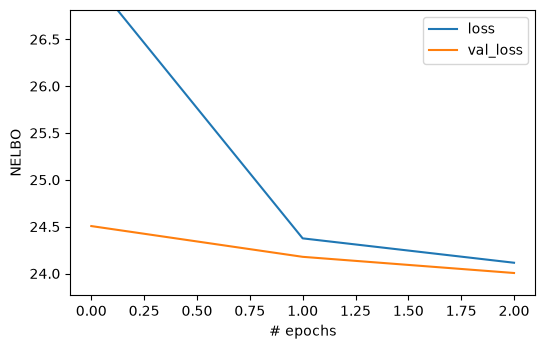

In [5]:
fig, ax = plt.subplots(figsize=(6, 6/1.618))
hist_df = pd.DataFrame(history.history)
hist_df.plot(ax=ax)
ax.set_ylabel('NELBO')
ax.set_xlabel('# epochs')
ax.set_ylim(0.99 * hist_df.iloc[1:].values.min(),
            1.1 * hist_df.iloc[1:].values.max())
plt.show()

## Visualizing embedding in latent space

Since our latent space is two dimensional, we can think of our encoder as defining a dimensional reduction of the original 784 dimensional space to just two dimensions! We can visualize the structure of this mapping by plotting the MNIST dataset in the latent space, with each point colored by which number it is $[0,1,\ldots,9]$.

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


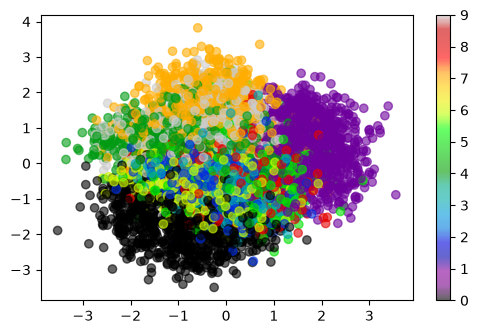

In [6]:
x_test_encoded = encoder.predict(x_test, batch_size=batch_size)
plt.figure(figsize=(6, 6/1.618))
plt.scatter(x_test_encoded[:, 0], x_test_encoded[:, 1],
            c=y_test, cmap='nipy_spectral', alpha=0.6)
plt.colorbar()
plt.savefig('VAE_MNIST_latent.pdf')
plt.show()


## Generating new examples

One of the nice things about VAEs is that they are generative models. Thus, we can generate new examples or fantasy particles much like we did for RBMs and DBMs. We will generate the particles in two different ways

* Sampling uniformally in the latent space 
* Sampling accounting for the fact that the latent space is Gaussian so that we expect most of the data points to be centered around (0,0) and fall off exponentially in all directions. This is done by transforming the uniform grid using the inverse Cumulative Distribution Function (CDF) for the Gaussian.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


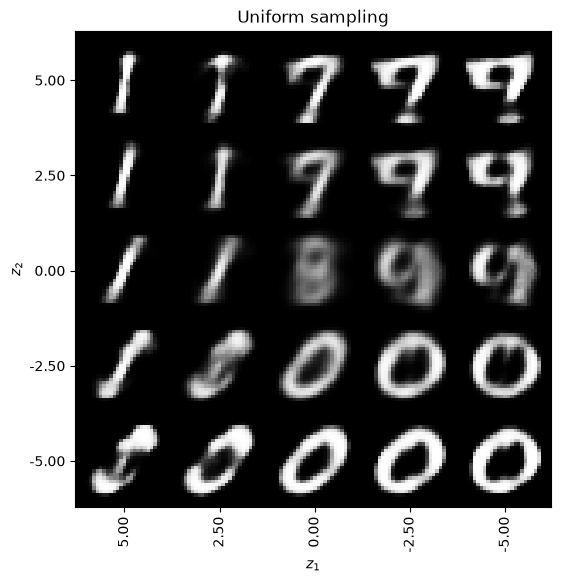

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


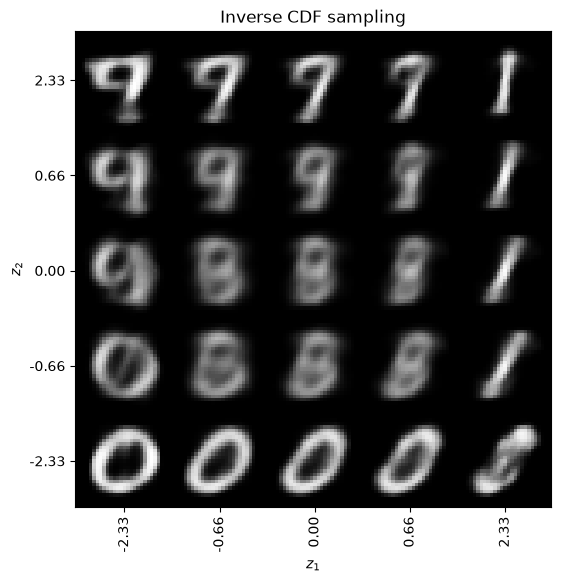

In [7]:
# -------------------- Generation (uniform grid) --------------------
n = 5
z1_u = np.linspace(5, -5, n)
z2_u = np.linspace(5, -5, n)
z_grid = np.dstack(np.meshgrid(z1_u, z2_u)).reshape(-1, latent_dim)

x_pred_grid = decoder.predict(z_grid).reshape(n, n, 28, 28)

fig, ax = plt.subplots(figsize=(10, 10/1.618))
ax.imshow(np.block(list(map(list, x_pred_grid))), cmap='gray')
ax.set_xticks(np.arange(0, n*28, 28) + 14)
ax.set_xticklabels([f'{v:.2f}' for v in z1_u], rotation=90)
ax.set_yticks(np.arange(0, n*28, 28) + 14)
ax.set_yticklabels([f'{v:.2f}' for v in z2_u])
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
ax.set_title('Uniform sampling')
ax.grid(False)
plt.savefig('VAE_MNIST_fantasy_uniform.pdf')
plt.show()

# -------------------- Generation (inverse CDF) --------------------
quantile_min, quantile_max = 0.01, 0.99
z1 = norm.ppf(np.linspace(quantile_min, quantile_max, n))
z2 = norm.ppf(np.linspace(quantile_max, quantile_min, n))
z_grid2 = np.dstack(np.meshgrid(z1, z2)).reshape(-1, latent_dim)

x_pred_grid2 = decoder.predict(z_grid2).reshape(n, n, 28, 28)

fig, ax = plt.subplots(figsize=(10, 10/1.618))
ax.imshow(np.block(list(map(list, x_pred_grid2))), cmap='gray')
ax.set_xticks(np.arange(0, n*28, 28) + 14)
ax.set_xticklabels([f'{v:.2f}' for v in z1], rotation=90)
ax.set_yticks(np.arange(0, n*28, 28) + 14)
ax.set_yticklabels([f'{v:.2f}' for v in z2])
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
ax.set_title('Inverse CDF sampling')
ax.grid(False)
plt.savefig('VAE_MNIST_fantasy_invCDF.pdf')
plt.show()

## Exercises

* Play with the standard deviation of the latent variables $\epsilon$. How does this effect your results?
* Generate samples as you increase the number of latent dimensions. Do your generated samples look better? Visualize the latent variables using a dimensional reduction technique such as PCA or t-SNE. How does it compare to the case with two latent dimensions showed above?
* Repeat this analysis with the supersymmetry dataset? Are the supersymmetric and non-supersymmetric examples separated in the latent dimensions?